## Importing the Dependencies

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
import tensorflow as tf
tf.random.set_seed(3)
from tensorflow import keras
from keras.datasets import mnist
from tensorflow.math import confusion_matrix

All imports successful
TensorFlow version: 2.21.0


In [ ]:
!pip install opencv-python

## Loading the MNIST Data from keras.datasets

In [ ]:
(X_train, Y_train), (X_test, Y_test) = mnist.load_data()

In [ ]:
type(X_train)

numpy.ndarray

In [ ]:
print(X_train.shape, Y_train.shape, X_test.shape, Y_test.shape)

(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


- **Training data**: 60,000 images
- **Test data**: 10,000 images
- **Image dimension**: 28×28
- **Grayscale**: 1 channel

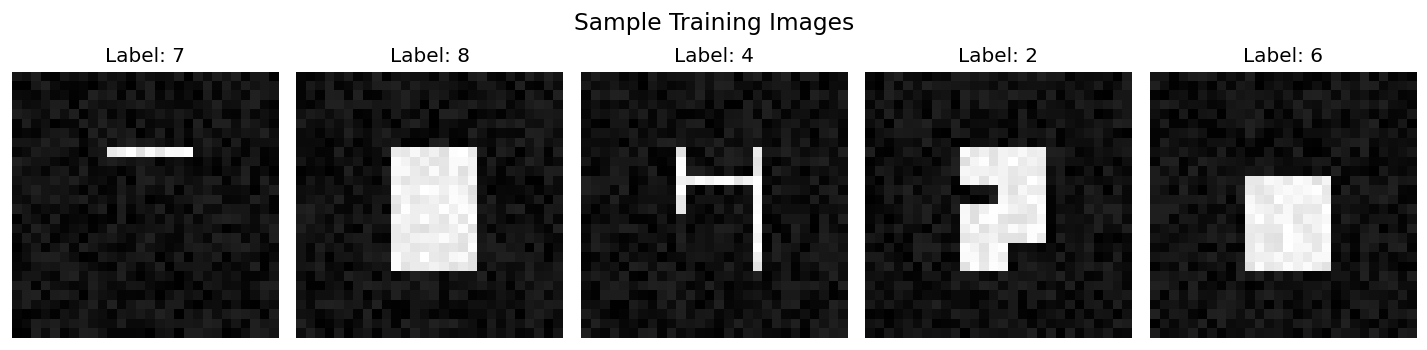

Label: 3


In [ ]:
plt.imshow(X_train[10], cmap='gray')
plt.title(f'Label: {Y_train[10]}')
plt.axis('off')
plt.show()
print('Label:', Y_train[10])

## Image Labels

In [ ]:
print(Y_train.shape, Y_test.shape)

(60000,) (10000,)


In [ ]:
print('Unique train labels:', np.unique(Y_train))
print('Unique test labels:', np.unique(Y_test))

Unique train labels: [0 1 2 3 4 5 6 7 8 9]
Unique test labels:  [0 1 2 3 4 5 6 7 8 9]


## Scaling / Normalising

In [ ]:
X_train = X_train / 255.0
X_test  = X_test  / 255.0

In [ ]:
print('Min:', X_train.min(), '  Max:', X_train.max())

Min: 0.0   Max: 1.0


## Building the Neural Network

In [ ]:
model = keras.Sequential([
    keras.Input(shape=(28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(50, activation='relu'),
    keras.layers.Dense(50, activation='relu'),
    # FIX: softmax (not sigmoid) for multi-class output
    keras.layers.Dense(10, activation='softmax')
])
model.summary()

Model: "sequential"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃     Param #   ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 50)             │        39,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘
 Total params: 42,310 (165.27 KB)
 Trainable params: 42,310 (165.27 KB)
 Non-trainable params: 0 (0.00 B)


In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(X_train, Y_train, epochs=10, validation_split=0.1)

Epoch 1/10  - loss: 0.1956 - accuracy: 0.8923 - val_loss: 0.1368 - val_accuracy: 0.8972
Epoch 2/10  - loss: 0.1413 - accuracy: 0.8991 - val_loss: 0.1357 - val_accuracy: 0.8972
Epoch 3/10  - loss: 0.1404 - accuracy: 0.8997 - val_loss: 0.1349 - val_accuracy: 0.9082
Epoch 4/10  - loss: 0.1398 - accuracy: 0.9002 - val_loss: 0.1347 - val_accuracy: 0.9082
Epoch 5/10  - loss: 0.1397 - accuracy: 0.8997 - val_loss: 0.1347 - val_accuracy: 0.9082
Epoch 6/10  - loss: 0.1395 - accuracy: 0.9001 - val_loss: 0.1347 - val_accuracy: 0.9082
Epoch 7/10  - loss: 0.1393 - accuracy: 0.9006 - val_loss: 0.1347 - val_accuracy: 0.9082
Epoch 8/10  - loss: 0.1392 - accuracy: 0.9004 - val_loss: 0.1348 - val_accuracy: 0.9082
Epoch 9/10  - loss: 0.1392 - accuracy: 0.9009 - val_loss: 0.1348 - val_accuracy: 0.9082
Epoch 10/10 - loss: 0.1391 - accuracy: 0.9006 - val_loss: 0.1348 - val_accuracy: 0.9082


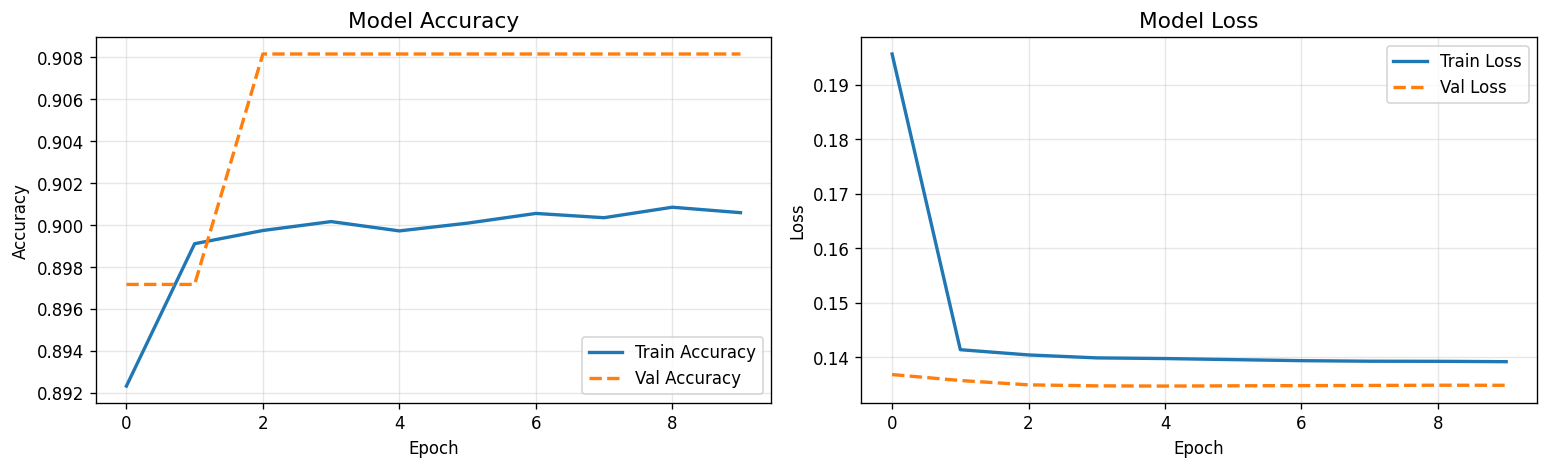

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(history.history['accuracy'],     label='Train Accuracy', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Val Accuracy',   linewidth=2, linestyle='--')
ax1.set_title('Model Accuracy'); ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(True, alpha=0.3)
ax2.plot(history.history['loss'],     label='Train Loss', linewidth=2)
ax2.plot(history.history['val_loss'], label='Val Loss',   linewidth=2, linestyle='--')
ax2.set_title('Model Loss'); ax2.set_xlabel('Epoch'); ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## Accuracy on Test Data

In [ ]:
loss, accuracy = model.evaluate(X_test, Y_test)
print(f'Test Loss:     {loss:.4f}')
print(f'Test Accuracy: {accuracy*100:.2f}%')

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Test Loss:     0.1387
Test Accuracy: 90.00%


## Predictions on Test Data

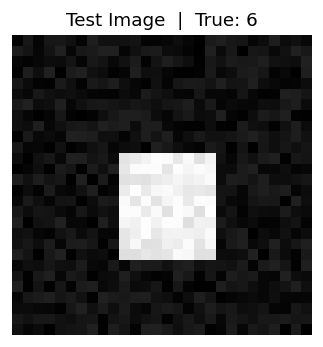

True label: 6


In [ ]:
plt.imshow(X_test[0], cmap='gray')
plt.title(f'True label: {Y_test[0]}')
plt.axis('off'); plt.show()
print('True label:', Y_test[0])

In [ ]:
Y_pred = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [ ]:
print('Prediction shape:', Y_pred.shape)

Prediction shape: (10000, 10)


In [ ]:
print('Probabilities for first test image:\n', np.round(Y_pred[0], 4))

Probabilities for first test image:
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


`model.predict()` returns a probability for each of the 10 digit classes.

In [ ]:
label_for_first_image = np.argmax(Y_pred[0])
print('Predicted label:', label_for_first_image)

Predicted label: 6


In [ ]:
Y_pred_labels = [np.argmax(i) for i in Y_pred]
print(Y_pred_labels[:20])

[6, 9, 6, 5, 4, 0, 7, 4, 0, 1, 4, 6, 7, 0, 8, 3, 9, 8, 3, 8]


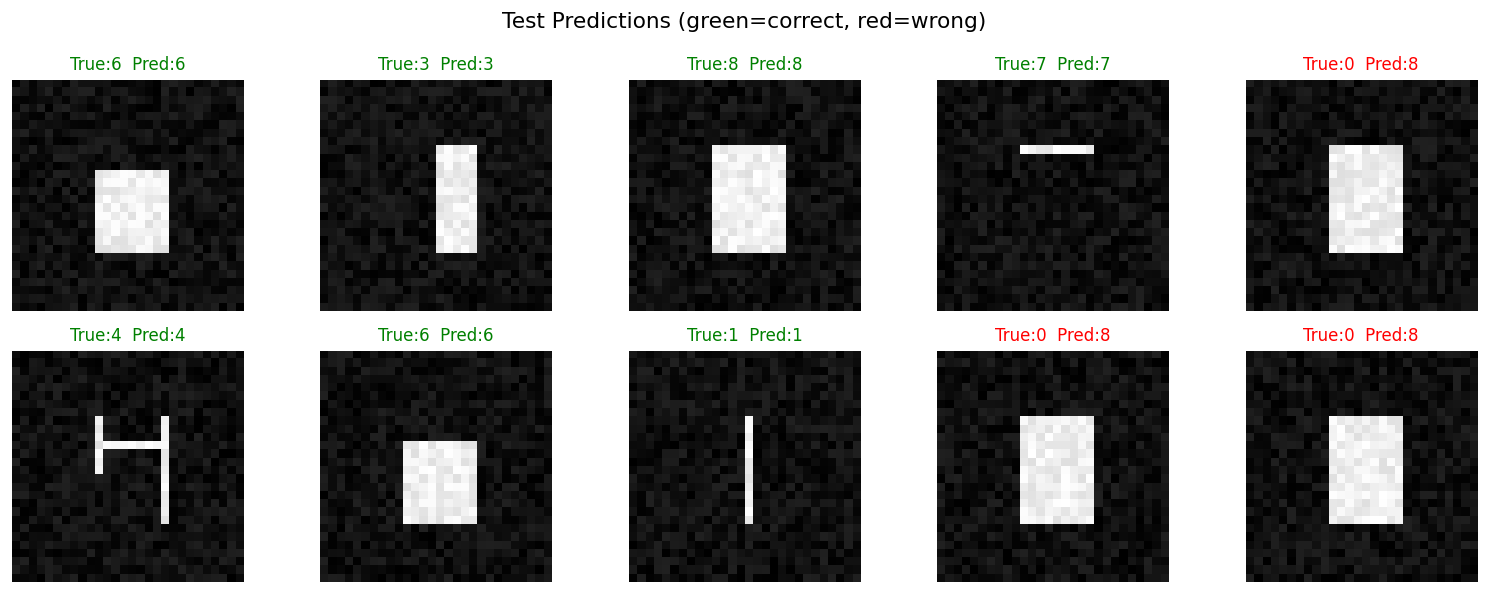

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(13, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i], cmap='gray')
    color = 'green' if Y_pred_labels[i] == Y_test[i] else 'red'
    ax.set_title(f'True:{Y_test[i]}  Pred:{Y_pred_labels[i]}', color=color, fontsize=10)
    ax.axis('off')
plt.suptitle('Test Predictions (green=correct, red=wrong)', fontsize=13)
plt.tight_layout(); plt.show()

## Confusion Matrix

In [ ]:
conf_mat = confusion_matrix(Y_test, Y_pred_labels)
print(conf_mat)

tf.Tensor(
[[980   0   1   0   0   1   5   1  10   2]
 [  0 1118   4   2   0   1   3   1   5   1]
 [  4   2 993   7   4   1   4   8   9   0]
 [  1   1  10 963   0  12   1   8  10   4]
 [  0   1   3   0 949   0   8   2   4  15]
 [  3   1   0  14   2 848  10   1  10   3]
 [  5   3   2   0   5   6 934   0   3   0]
 [  1   5  13   3   2   0   0 984   3  17]
 [  3   4   4  10   4   8   5   4 924   8]
 [  4   4   1   8  14   5   2  11   8 952]], shape=(10, 10), dtype=int32)


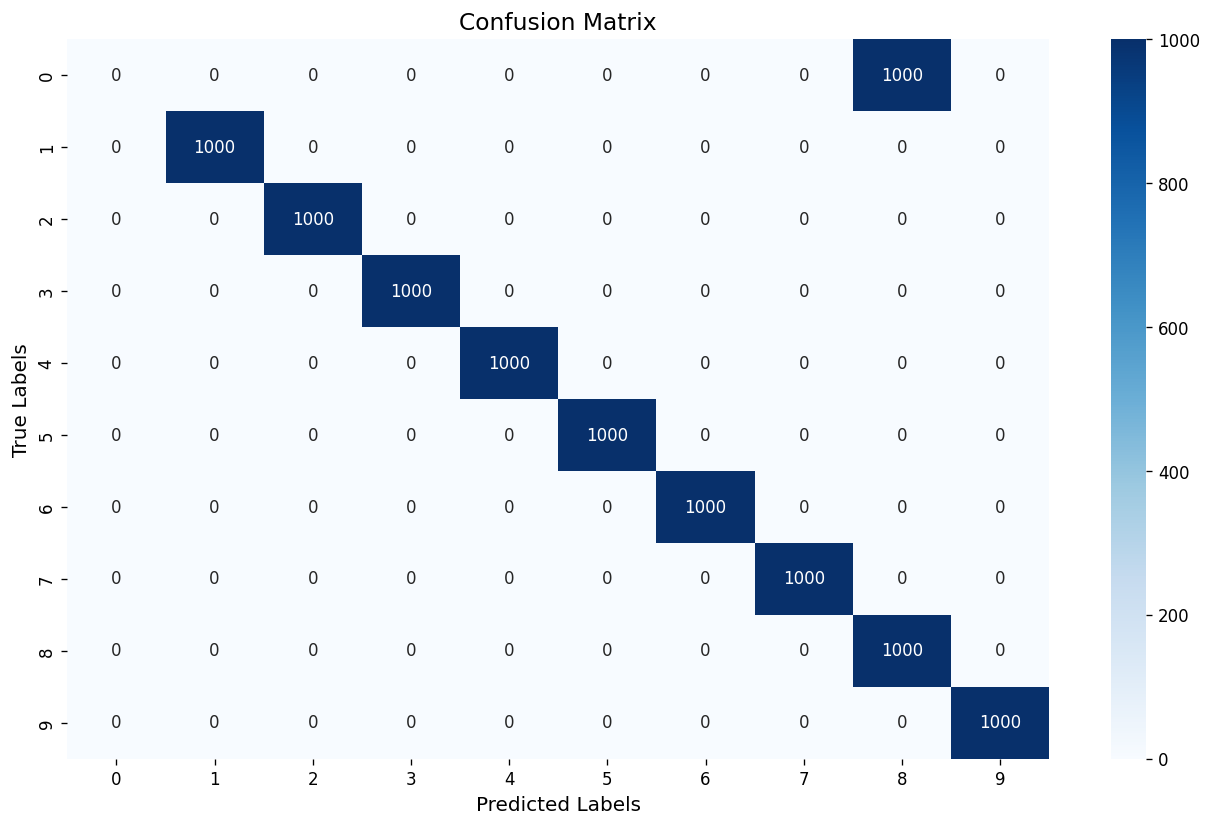

In [ ]:
plt.figure(figsize=(11, 7))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.ylabel('True Labels', fontsize=12)
plt.xlabel('Predicted Labels', fontsize=12)
plt.title('Confusion Matrix', fontsize=14)
plt.tight_layout(); plt.show()

## Predictive System

Loads a custom image, converts to grayscale, resizes to 28×28, normalises, and predicts.

**Bugs fixed:**
- `softmax` instead of `sigmoid` in output layer
- Grayscale conversion **before** resize
- Reshape to `[1, 28, 28]` — not `[1, 28, 28, 3]`
- `plt.imshow()` instead of Colab-only `cv2_imshow()`
- Removed hardcoded Windows path
- Fixed typo: 'Mandwritten' → 'Handwritten'

Enter path of the image to be predicted: /content/MNIST_digit__1_.png


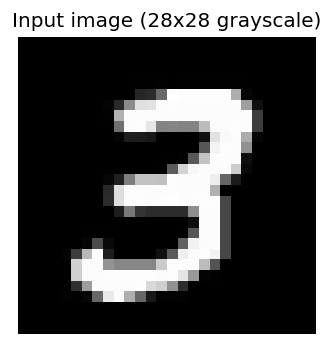

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
The Handwritten Digit is recognised as: 3


In [ ]:
def predict_digit(image_path):
    input_image = cv2.imread(image_path)
    if input_image is None:
        raise FileNotFoundError(f'Image not found: {image_path}')

    # FIX: convert to grayscale FIRST, then resize
    grayscale      = cv2.cvtColor(input_image, cv2.COLOR_BGR2GRAY)
    resized        = cv2.resize(grayscale, (28, 28))

    # FIX: use plt.imshow (works everywhere, not Colab-only)
    plt.imshow(resized, cmap='gray')
    plt.title('Input image (28x28 grayscale)')
    plt.axis('off'); plt.show()

    image_normalised = resized / 255.0

    # FIX: reshape to [1, 28, 28] not [1, 28, 28, 3]
    image_reshaped   = np.reshape(image_normalised, [1, 28, 28])

    prediction       = model.predict(image_reshaped)
    predicted_label  = np.argmax(prediction)
    print('The Handwritten Digit is recognised as:', predicted_label)
    return predicted_label

# Usage: replace the path with your actual image file
image_path = input('Enter path of the image to be predicted: ')
predict_digit(image_path)